In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
import psutil
import os
import time
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import quantile_transform

In [2]:
import numpy as np
from scipy.stats import ttest_ind
import pandas as pd
# from scipy.stats import chisquare
# from statsmodels.tools.tools import add_constant
# from statsmodels.stats.outliers_influence import variance_inflation_factor
import time
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, chi2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import psutil
import os
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score, ConfusionMatrixDisplay
import xlwings as xw

# Load dataset



In [3]:
def Normalization(X_Train):
    value_Train=[]
    key_Train=[]
    for i in(X_Train.columns):
        if X_Train[i].std()==0:
            key_Train.append(i)
            value_Train.append(X_Train[i].max())    
    X_Train=(X_Train-X_Train.min())/(X_Train.max()-X_Train.min())
    for i in (X_Train.columns):
        for j in range(len(key_Train)):
            if key_Train[j]==i:
                if value_Train[j]<=0:
                    X_Train[i]=0
                elif value_Train[j]>0:
                    X_Train[i]=1
    return X_Train
def Quantile_Transform(X_Train):
    qt=quantile_transform(X_Train,  random_state=0, copy=True)
    X_QT = pd.concat([pd.DataFrame(qt)], axis=1)
    return X_QT

def Standardization(X_Train):
    std = (X_Train - X_Train.mean()) / X_Train.std()
    X_STD = pd.concat([pd.DataFrame(std, columns=X_Train.columns)], axis=1)
    return X_STD

In [4]:
# Step 1: Load the dataset
df = pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_BINARY_CLASS_4L.csv')

# #BASELINE_76F
# Features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets','Total Length of Fwd Packets', 
#             'Total Length of Bwd Packets','Fwd Packet Length Max', 'Fwd Packet Length Min','Fwd Packet Length Mean',
#             'Fwd Packet Length Std','Bwd Packet Length Max', 'Bwd Packet Length Min','Bwd Packet Length Mean',
#             'Bwd Packet Length Std', 'Flow Bytes/s','Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
#             'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std','Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 
#             'Bwd IAT Mean','Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags','Bwd PSH Flags', 'Fwd URG Flags', 
#             'Bwd URG Flags', 'Fwd Header Length','Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s','Min Packet Length',
#             'Max Packet Length', 'Packet Length Mean','Packet Length Std', 'Packet Length Variance', 'FIN Flag Count','SYN Flag Count', 
#             'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count','URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 
#             'Down/Up Ratio','Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size','Fwd Avg Bytes/Bulk', 
#             'Fwd Avg Packets/Bulk','Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk','Bwd Avg Bulk Rate', 
#             'Subflow Fwd Packets', 'Subflow Fwd Bytes','Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward',
#             'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward','Active Mean', 'Active Std', 'Active Max', 
#             'Active Min', 'Idle Mean','Idle Std', 'Idle Max', 'Idle Min',
#             'Label']

#SHAPLEY_42F
# Features = ['Inbound','URG Flag Count','Bwd Packets/s','Total Backward Packets','Min Packet Length','Bwd IAT Total',
#                 'Bwd IAT Max','Total Length of Bwd Packets','Down/Up Ratio','Fwd Packet Length Min','Average Packet Size',
#                 'Init_Win_bytes_backward','Fwd Packet Length Max','Bwd Packet Length Max','Bwd IAT Min',
#                 'Init_Win_bytes_forward','Bwd IAT Mean','ACK Flag Count','Fwd Packet Length Mean','Flow Bytes/s',
#                 'CWE Flag Count','min_seg_size_forward','Packet Length Mean','act_data_pkt_fwd','Packet Length Variance',
#                 'Total Length of Fwd Packets','Packet Length Std','Bwd Header Length','Fwd PSH Flags','Max Packet Length',
#                 'Fwd Header Length','Bwd Packet Length Mean','Flow IAT Mean','Total Fwd Packets','Fwd IAT Mean','Flow Duration',
#                 'Fwd Packet Length Std','Flow IAT Std','Fwd IAT Total','Flow IAT Max','Bwd Packet Length Min','Flow Packets/s',
#                 'Label']
#12F after Z-Test
# Features = ['Inbound','Max Packet Length','Min Packet Length','Fwd Packet Length Min','Average Packet Size','Init_Win_bytes_backward',
#             'Fwd Packet Length Max','Init_Win_bytes_forward','Fwd Packet Length Mean','Flow Bytes/s','Packet Length Mean','Flow Packets/s',
#              'Label']
#6F after Chi_Sq-Test
# Features = ['Min Packet Length','Average Packet Size','Init_Win_bytes_forward',
#             'Fwd Packet Length Mean','Flow Bytes/s','Fwd Packet Length Min',
#             'Label']
#SHAP-LIME_35F
# Features = ['URG Flag Count','Bwd Packets/s','Packet Length Mean','Fwd PSH Flags','Bwd Packet Length Max',
#             'Packet Length Variance','Bwd Header Length','Total Backward Packets','Min Packet Length','Init_Win_bytes_forward',
#             'Down/Up Ratio','Total Length of Bwd Packets','CWE Flag Count','Bwd IAT Max','Fwd Packet Length Max',
#             'Packet Length Std','Fwd Packet Length Min','Average Packet Size','Fwd Packet Length Mean','Bwd Packet Length Min',
#             'Max Packet Length','Bwd IAT Total','min_seg_size_forward','Flow IAT Max','Flow IAT Std',
#             'Flow IAT Mean','Total Length of Fwd Packets','Total Fwd Packets','act_data_pkt_fwd','Bwd IAT Min',
#             'ACK Flag Count','Fwd Header Length','Fwd IAT Mean','Bwd IAT Mean','Flow Packets/s',
#             'Label']

#SHAP_X_50F
# Features = ['Inbound','ACK Flag Count','URG Flag Count','Min Packet Length','Bwd Packets/s',
#             'Bwd Header Length','Init_Win_bytes_forward','Fwd Packet Length Min','Total Backward Packets','Fwd Packet Length Max',
#             'Fwd Packet Length Mean','Down/Up Ratio','Average Packet Size','Bwd IAT Max','Bwd IAT Min',
#             'Total Length of Fwd Packets','Max Packet Length','Fwd Packets/s','Init_Win_bytes_backward','Packet Length Mean',
#             'Bwd Packet Length Mean','Packet Length Std','Bwd IAT Mean','Packet Length Variance','Fwd Header Length',
#             'Flow Bytes/s','Bwd IAT Total','Flow IAT Std','min_seg_size_forward','act_data_pkt_fwd',
#             'Avg Bwd Segment Size','Fwd PSH Flags','Fwd IAT Max','CWE Flag Count','Flow IAT Max',
#             'Flow Packets/s','Flow Duration','Total Length of Bwd Packets','Bwd Packet Length Max','Flow IAT Mean',
#             'Fwd IAT Std','Bwd Packet Length Min','Fwd IAT Mean','Fwd IAT Total','Total Fwd Packets',
#             'Fwd Packet Length Std','Active Min','Idle Max','Flow IAT Min','Fwd IAT Min',
#             'Label']

#SHAP_X-test_49F
# Features = ['Inbound','URG Flag Count','Bwd Packets/s','Total Backward Packets','ACK Flag Count','Min Packet Length','Bwd Header Length',
#             'Fwd Packet Length Mean','Init_Win_bytes_forward','Fwd Packet Length Min','Bwd IAT Mean','Packet Length Mean','Bwd Packet Length Max','Down/Up Ratio',
#             'Bwd IAT Min','Bwd IAT Max','Total Length of Fwd Packets','Max Packet Length','Average Packet Size','Fwd Packet Length Max','Fwd Header Length',
#             'Init_Win_bytes_backward','Packet Length Variance','Flow Bytes/s','Bwd Packet Length Mean','min_seg_size_forward','Packet Length Std','CWE Flag Count',
#             'Bwd Packet Length Min','act_data_pkt_fwd','Avg Bwd Segment Size','Total Length of Bwd Packets','Flow Packets/s','Fwd Packets/s','Flow IAT Std',
#             'Bwd IAT Total','Flow Duration','Fwd PSH Flags','Flow IAT Mean','Fwd IAT Mean','Total Fwd Packets','Flow IAT Max',
#             'Fwd IAT Std','Fwd Packet Length Std','Fwd IAT Total','Fwd IAT Max','Flow IAT Min','Active Min','Active Mean',
#             'Label']

#LIME_X-test_54F
# Features = ['URG Flag Count','Bwd Packets/s','Bwd Packet Length Max','Total Backward Packets','Bwd Header Length','Fwd PSH Flags','Min Packet Length','Init_Win_bytes_forward','Avg Bwd Segment Size',
#             'Bwd IAT Max','Packet Length Variance','Fwd Packet Length Min','Total Length of Bwd Packets','Fwd Packet Length Mean','SYN Flag Count','Bwd IAT Min','Average Packet Size','Bwd Packet Length Min',
#             'Packet Length Mean','Packet Length Std','Down/Up Ratio','Flow IAT Min','Fwd Packet Length Max','Bwd IAT Total','min_seg_size_forward','Max Packet Length','CWE Flag Count',
#             'Active Max','Flow IAT Std','Bwd Packet Length Mean','Active Mean','Bwd Packet Length Std','Fwd Packet Length Std','Fwd IAT Min','Idle Std','Total Length of Fwd Packets',
#             'Active Std','act_data_pkt_fwd','Fwd IAT Std','Bwd IAT Std','Fwd Header Length','Idle Max','Idle Mean','Active Min','Idle Min',
#             'Flow Packets/s','Fwd IAT Total','Fwd Packets/s','Flow Duration','Fwd IAT Mean','Flow IAT Mean','Flow Bytes/s','Total Fwd Packets','Bwd IAT Mean',
#             'Label']
#LIME_X_55F
# Features = ['URG Flag Count','SYN Flag Count','Bwd Packets/s','CWE Flag Count','Total Length of Bwd Packets',
#             'Down/Up Ratio','Fwd PSH Flags','Init_Win_bytes_forward','Bwd Header Length','Total Backward Packets',
#             'Bwd Packet Length Max','Flow IAT Min','Bwd Packet Length Std','Bwd IAT Std','Packet Length Variance',
#             'Max Packet Length','Fwd IAT Min','Bwd IAT Max','Active Std','Bwd IAT Total',
#             'Idle Std','Fwd Packet Length Min','Active Mean','Bwd Packet Length Min','Bwd Packet Length Mean',
#             'Active Max','Idle Min','Active Min','Idle Max','Fwd IAT Std',
#             'Idle Mean','Bwd IAT Min','Min Packet Length','Avg Bwd Segment Size','ACK Flag Count',
#             'Packet Length Std','Packet Length Mean','Flow IAT Mean','Average Packet Size','Fwd Packet Length Std',
#             'Flow IAT Max','Bwd IAT Mean','Fwd IAT Mean','act_data_pkt_fwd','Flow IAT Std',
#             'Total Fwd Packets','Fwd Packet Length Mean','Fwd Packet Length Max','Flow Bytes/s','min_seg_size_forward',
#             'Flow Duration','Fwd IAT Total','Fwd Header Length','Fwd IAT Max','Total Length of Fwd Packets',
#             'Label']

#LIME_ALL_55F
# Features = ['URG Flag Count','SYN Flag Count','Bwd Packets/s','CWE Flag Count','Total Length of Bwd Packets','Down/Up Ratio',
#             'Fwd PSH Flags','Init_Win_bytes_forward','Bwd Header Length','Total Backward Packets','Bwd Packet Length Max',
#             'Flow IAT Min','Bwd Packet Length Std','Bwd IAT Std','Packet Length Variance','Max Packet Length','Fwd IAT Min',
#             'Bwd IAT Max','Active Std','Bwd IAT Total','Idle Std','Fwd Packet Length Min','Active Mean','Bwd Packet Length Min',
#             'Bwd Packet Length Mean','Active Max','Idle Min','Active Min','Idle Max','Fwd IAT Std','Idle Mean','Bwd IAT Min',
#             'Min Packet Length','Avg Bwd Segment Size','ACK Flag Count','Packet Length Std','Packet Length Mean','Flow IAT Mean',
#             'Average Packet Size','Fwd Packet Length Std','Flow IAT Max','Bwd IAT Mean','Fwd IAT Mean','act_data_pkt_fwd',
#             'Flow IAT Std','Total Fwd Packets','Fwd Packet Length Mean','Fwd Packet Length Max','Flow Bytes/s','min_seg_size_forward',
#             'Flow Duration','Fwd IAT Total','Fwd Header Length','Fwd IAT Max','Total Length of Fwd Packets',
#             'Label']

#LIME_54F
# Features = ['URG Flag Count','Fwd PSH Flags','Bwd Header Length','Bwd Packets/s','Bwd Packet Length Max','Total Backward Packets',
#             'Min Packet Length','Init_Win_bytes_forward','Packet Length Variance','Total Length of Bwd Packets','CWE Flag Count',
#             'Bwd IAT Total','Bwd IAT Min','Fwd Packet Length Min','Bwd Packet Length Mean','Fwd Packet Length Mean','Avg Bwd Segment Size',
#             'Bwd Packet Length Min','SYN Flag Count','Down/Up Ratio','Packet Length Mean','Fwd IAT Min','Average Packet Size',
#             'Packet Length Std','Bwd IAT Max','Flow IAT Min','Bwd IAT Mean','min_seg_size_forward','Fwd Packet Length Max',
#             'Total Length of Fwd Packets','Max Packet Length','Flow IAT Std','Total Fwd Packets','Active Mean','Flow Bytes/s',
#             'Bwd IAT Std','act_data_pkt_fwd','Bwd Packet Length Std','Active Min','Fwd Header Length','ACK Flag Count',
#             'Fwd IAT Max','Fwd Packet Length Std','Active Std','Idle Std','Active Max','Idle Mean',
#             'Idle Min','Idle Max','Flow Packets/s','Flow IAT Mean','Fwd IAT Total','Fwd IAT Mean','Flow IAT Max',
#             'Label']

#LIME_55F + 8F
# Features = ['URG Flag Count','SYN Flag Count','Init_Win_bytes_forward','Fwd PSH Flags','Bwd Packet Length Mean','Total Length of Bwd Packets',
#             'Bwd Header Length','Avg Bwd Segment Size','Fwd IAT Min','Down/Up Ratio','CWE Flag Count','Bwd Packets/s',
#             'Bwd Packet Length Min','Flow IAT Min','Packet Length Variance','Bwd Packet Length Std','Bwd IAT Mean','Bwd Packet Length Max',
#             'Active Std','Active Max','Bwd IAT Std','Max Packet Length','Idle Std','Active Mean',
#             'Idle Max','Idle Min','Active Min','Idle Mean','Fwd Packet Length Max','Bwd IAT Total','Packet Length Std',
#             'Average Packet Size','Fwd IAT Std','min_seg_size_forward','Fwd Packet Length Mean','Bwd IAT Min','Min Packet Length',
#             'Total Backward Packets','Bwd IAT Max','Fwd Packet Length Min','Fwd Packet Length Std','act_data_pkt_fwd','ACK Flag Count',
#             'Flow Bytes/s','Flow IAT Std','Flow IAT Mean','Total Fwd Packets','Packet Length Mean','Fwd IAT Mean',
#             'Flow Duration','Flow IAT Max','Fwd IAT Total','Fwd Header Length','Fwd IAT Max','Total Length of Fwd Packets',
#             'Label']

#W8F_LIME_55F
# Features = ['ACK Flag Count','act_data_pkt_fwd','Active Max','Active Mean','Active Min','Active Std','Average Packet Size','Avg Bwd Segment Size',
#             'Bwd Header Length','Bwd IAT Max','Bwd IAT Mean','Bwd IAT Min','Bwd IAT Std','Bwd IAT Total','Bwd Packet Length Max',
#             'Bwd Packet Length Mean','Bwd Packet Length Min','Bwd Packet Length Std','Bwd Packets/s','CWE Flag Count','Down/Up Ratio',
#             'Flow Bytes/s','Flow IAT Max','Flow IAT Mean','Flow IAT Min','Flow Packets/s','Fwd Header Length','Fwd IAT Max','Fwd IAT Mean',
#             'Fwd IAT Min','Fwd IAT Std','Fwd IAT Total','Fwd Packet Length Max','Fwd Packet Length Mean','Fwd Packet Length Min',
#             'Fwd Packet Length Std','Fwd Packets/s','Fwd PSH Flags','Idle Max','Idle Mean','Idle Min','Idle Std','Init_Win_bytes_forward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Packet Length Mean','Packet Length Std','Packet Length Variance',
#             'SYN Flag Count','Total Backward Packets','Total Fwd Packets','Total Length of Bwd Packets','Total Length of Fwd Packets','URG Flag Count',
#             'Label']
#WO_8F_LIME_54F
# Features = ['ACK Flag Count','act_data_pkt_fwd','Active Max','Active Mean','Active Min','Active Std','Average Packet Size','Avg Bwd Segment Size',
#             'Bwd Header Length','Bwd IAT Max','Bwd IAT Mean','Bwd IAT Min','Bwd IAT Std','Bwd IAT Total','Bwd Packet Length Max',
#             'Bwd Packet Length Mean','Bwd Packet Length Min','Bwd Packet Length Std','Bwd Packets/s','CWE Flag Count',
#             'Down/Up Ratio','Flow Bytes/s','Flow IAT Mean','Flow IAT Min','Flow IAT Std','Fwd Header Length','Fwd IAT Max',
#             'Fwd IAT Mean','Fwd IAT Min','Fwd IAT Std','Fwd IAT Total','Fwd Packet Length Max','Fwd Packet Length Mean','Fwd Packet Length Min',
#             'Fwd Packet Length Std','Fwd Packets/s','Fwd PSH Flags','Idle Max','Idle Mean','Idle Min','Idle Std','Init_Win_bytes_forward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Packet Length Mean','Packet Length Std','Packet Length Variance',
#             'SYN Flag Count','Total Backward Packets','Total Fwd Packets','Total Length of Bwd Packets','Total Length of Fwd Packets','URG Flag Count',
#             'Label']

#LIME-SHAP_48F
# Features = ['ACK Flag Count','Min Packet Length','Bwd Packets/s','Init_Win_bytes_forward','URG Flag Count',
#             'Bwd Header Length','Total Backward Packets','Fwd Packet Length Mean','Fwd Packet Length Min',
#             'Average Packet Size','Max Packet Length','Packet Length Mean','Down/Up Ratio','Avg Bwd Segment Size',
#             'Fwd Packet Length Max','Flow Bytes/s','Bwd IAT Min','Packet Length Std','Bwd IAT Mean','Bwd IAT Max',
#             'Bwd Packet Length Max','Packet Length Variance','Total Length of Bwd Packets','Fwd Header Length','min_seg_size_forward',
#             'Bwd Packet Length Mean','Bwd IAT Total','act_data_pkt_fwd','Flow IAT Mean','Flow Duration','Total Length of Fwd Packets',
#             'Total Fwd Packets','Flow IAT Std','Fwd IAT Total','Fwd PSH Flags','Flow IAT Max','Fwd IAT Mean','Fwd IAT Max',
#             'Bwd Packet Length Min','CWE Flag Count','Active Min','Fwd Packet Length Std','Fwd IAT Std','Active Mean','Fwd IAT Min',
#             'Active Max','Flow IAT Min','Idle Mean',
#             'Label']

#LIME_ALL_55F_MEAN_12F-7F
# Features = ['URG Flag Count','SYN Flag Count','Bwd Packets/s','CWE Flag Count','Total Length of Bwd Packets',
#             'Down/Up Ratio','Fwd PSH Flags',
#             'Label']

#LIME_ALL_55F_MEDIAN_34F-27F
# Features = ['URG Flag Count','SYN Flag Count','Bwd Packets/s','CWE Flag Count','Total Length of Bwd Packets','Down/Up Ratio',
#             'Fwd PSH Flags','Init_Win_bytes_forward','Bwd Header Length','Total Backward Packets','Bwd Packet Length Max','Flow IAT Min',
#             'Bwd Packet Length Std','Bwd IAT Std','Packet Length Variance','Max Packet Length','Fwd IAT Min','Bwd IAT Max',
#             'Active Std','Bwd IAT Total','Idle Std','Fwd Packet Length Min','Active Mean','Bwd Packet Length Min',
#             'Bwd Packet Length Mean','Active Max','Idle Min',
#             'Label']

#SHAP_MEDIAN_33F-27F
# Features = ['Inbound','URG Flag Count','Bwd Packets/s','Total Backward Packets','Min Packet Length','Bwd IAT Total',
#             'Bwd IAT Max','Total Length of Bwd Packets','Down/Up Ratio','Fwd Packet Length Min','Average Packet Size','Init_Win_bytes_backward',
#             'Fwd Packet Length Max','Bwd Packet Length Max','Bwd IAT Min','Init_Win_bytes_forward','Bwd IAT Mean','ACK Flag Count',
#             'Fwd Packet Length Mean','Flow Bytes/s','CWE Flag Count','min_seg_size_forward','Packet Length Mean','act_data_pkt_fwd',
#             'Packet Length Variance','Total Length of Fwd Packets',
#             'Label']
# PCA
# Features = ['act_data_pkt_fwd','Active Mean','Active Std','Bwd Header Length','Bwd IAT Min','Bwd IAT Std','Bwd Packet Length Min',
#             'Bwd Packets/s','CWE Flag Count','Flow IAT Max','Flow Packets/s','Fwd Header Length','Fwd IAT Min','Fwd Packet Length Max',
#             'Fwd Packet Length Std','Fwd PSH Flags','min_seg_size_forward','Packet Length Std','SYN Flag Count','Total Fwd Packets',
#             'Total Length of Bwd Packets','URG Flag Count',
#             'Label']

#Normalized Gain Ratio 46F
# Features = ['Inbound','URG Flag Count','Fwd PSH Flags','Down/Up Ratio','Bwd IAT Min','Total Backward Packets','CWE Flag Count',
#             'Bwd Header Length','Bwd Packet Length Max','Bwd Packet Length Min','Total Length of Bwd Packets','Bwd Packet Length Mean',
#             'Bwd IAT Max','Bwd IAT Total','Bwd IAT Mean','Init_Win_bytes_forward','Init_Win_bytes_backward','Bwd Packet Length Std',
#             'Packet Length Std','Packet Length Variance','Bwd Packets/s','SYN Flag Count','Bwd IAT Std','Active Min','Fwd Packet Length Std',
#             'Max Packet Length','Fwd Packet Length Max','Fwd Packet Length Mean','Packet Length Mean','Fwd Packet Length Min',
#             'Min Packet Length','Average Packet Size','Total Length of Fwd Packets','Flow IAT Std','Active Max','Active Mean','Flow Packets/s',
#             'Fwd Packets/s','Flow IAT Mean','Flow IAT Max','Flow Duration','Fwd Header Length','Active Std','min_seg_size_forward','Total Fwd Packets',
#             'Flow Bytes/s', 
#             'Label']

# PAPER_16_22F_MALDAVIFAR@2019
# Features= ['Fwd Packet Length Min','Packet Length Mean','Min Packet Length','Average Packet Size','Max Packet Length',
#           'Fwd Packet Length Mean','Avg Fwd Segment Size', 'Total Length of Fwd Packets','Subflow Fwd Bytes',
#           'Fwd Packet Length Max', 'Flow Bytes/s','Fwd Header Length','Fwd Header Length.1','Flow Duration',
#           'Flow IAT Mean','Fwd Packets/s','Flow Packets/s','Flow IAT Max','Fwd IAT Total', 'Fwd IAT Max','Fwd IAT Mean',
#           'Protocol',
#           'Label']

# PAPER_18_25F_J_HALLEDY@
# Features = ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
#             'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total',
#             'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
#             'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
#             'Bwd IAT Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min',
#             'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 
#             'Label']

#PAPER_24*_CIl et.al @69 FEATURES
# Features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
#        'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
#        'Fwd Packet Length Max', 'Fwd Packet Length Min',
#        'Fwd Packet Length Mean', 'Fwd Packet Length Std',
#        'Bwd Packet Length Max', 'Bwd Packet Length Min',
#        'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
#        'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
#        'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
#        'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
#        'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
#         'Fwd Header Length',
#        'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
#        'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
#        'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
#        'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
#        'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio',
#        'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
#         'Subflow Fwd Packets', 'Subflow Fwd Bytes',
#        'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward',
#        'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',
#        'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean',
#        'Idle Std', 'Idle Max', 'Idle Min', 'Inbound', 
#             'Label']

# PAPER_23_5F_RAJU@2022
# Features = ['Init_Win_bytes_forward','Min Packet Length','Inbound','Protocol','ACK Flag Count',
#            'Label']
# PAPER_23_6F_RAJU@2022
# Features = ['Total Backward Packets','Fwd Packet Length Min','URG Flag Count','Down/Up Ratio','Active Mean','Inbound',
#             'Label']

# PAPER_17_10F_G.C. Amaizu@2021
# Features = ['Fwd Packet Length Max','Flow Packets/s','Average Packet Size', 'Subflow Fwd Bytes','Avg Fwd Segment Size', 
#            'Flow IAT Std','Min Packet Length', 'Total Fwd Packets','Packet Length Variance','Protocol',
#            'Label']

# PAPER_19_20F_H.A.Alamri@
# Features = ['Protocol','Average Packet Size','Min Packet Length','Fwd Packet Length Mean','Avg Fwd Segment Size',
#             'Fwd Packet Length Min','Packet Length Mean','Fwd Packet Length Max','ACK Flag Count', 'Flow Bytes/s', 
#             'Source Port', 'Max Packet Length','Fwd Packets/s','Flow Packets/s','Subflow Fwd Bytes', 
#             'Total Length of Fwd Packets', 'Flow Duration', 'Fwd IAT Total','Source IP', 'Destination IP', 
#             'Label']

#PAPER_20_14F_A. A. Alashhab@
# Features = ['Flow Duration','Init_Win_bytes_forward', 'Average Packet Size','RST Flag Count','SYN Flag Count',
#             'FIN Flag Count','Packet Length Variance','Total Length of Fwd Packets', 'Total Length of Bwd Packets',
#             'Total Backward Packets','Total Fwd Packets', 'Flow Bytes/s','Flow Packets/s','Init_Win_bytes_backward',
#             'Label']

# PAPER_21_43F_NAJAR@:
Features = ['Total Fwd Packets', 'Total Backward Packets','Total Length of Fwd Packets', 'Fwd Packet Length Max', 
            'Fwd Packet Length Min','Fwd Packet Length Mean', 'Fwd Packet Length Std','Bwd Packet Length Mean', 
            'Flow Bytes/s','Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max','Flow IAT Min',  
            'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
            'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length','Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
            'Max Packet Length', 'Packet Length Mean','Packet Length Std', 'Packet Length Variance', 'Average Packet Size',
            'Avg Fwd Segment Size', 'Init_Win_bytes_forward','Init_Win_bytes_backward', 'act_data_pkt_fwd', 'Active Mean',
            'Active Std', 'Active Max', 'Active Min', 'Idle Mean','Idle Std', 'Idle Max', 'Idle Min', 
            'Label' ]

# PAPER_22_59F_Manthena R@
# Features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
#        'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
#        'Fwd Packet Length Max', 'Fwd Packet Length Min',
#        'Fwd Packet Length Mean', 'Fwd Packet Length Std',
#        'Bwd Packet Length Max', 'Bwd Packet Length Min',
#        'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
#        'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
#        'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
#        'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
#        'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
#        'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
#        'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
#        'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
#        'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count',
#        'CWE Flag Count', 'Down/Up Ratio', 'Average Packet Size',
#        'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
#        'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
#        'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
#        'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 
#             'Label']

#PAPER_25*_Wei, Y. et.al @20 FEATURES
# Features = ['Min Packet Length','Fwd Packet Length Mean','Fwd Packet Length Min','Average Packet Size',
#             'Fwd Packet Length Max','Max Packet Length','Protocol','Flow IAT Mean','Init_Win_bytes_forward',
#             'URG Flag Count','Flow Duration','Flow IAT Std','Flow IAT Min','Fwd Packets/s','Total Length of Fwd Packets',
#             'Fwd IAT Total','Total Fwd Packets','Total Backward Packets','act_data_pkt_fwd','Fwd IAT Mean',
#             'Label']

df=df[Features]
#df['Label']= [0 if x == 'BENIGN' else 1 for x in df['Label']]


C:\Users\asus\AppData\Local\Temp\ipykernel_20132\1549099645.py:2: DtypeWarning: Columns (84) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_BINARY_CLASS_4L.csv')


In [5]:
len(Features)

44

In [6]:
def ROC_AUC(y_test, y_pred,title):  
    fpr, tpr, thresholds = roc_curve(y_test, y_pred) 
    roc_auc = auc(fpr, tpr)
    #File=M+".png"
    #P=os.path.join(P_T,File)
    # Plot the ROC curve
    fig=plt.figure()  
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([-0.03, 1.05])
    plt.ylim([-0.03, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for '+ title)
    plt.legend()
   # plt.savefig(title+'.png')
    return fig

In [7]:
import xlwings as xw
def Evaluation_Metrics(y_test, y_pred_binary,Dataset_Name,Output_path):
    directory = os.path.join(Output_path, Dataset_Name)
    if not os.path.exists(directory):
        os.makedirs(directory)
    images_dir = os.path.join(directory, "images")
    os.makedirs(images_dir, exist_ok=True)
    sheet=wb.sheets.add(Dataset_Name) 
    Result=pd.DataFrame()
    Classifier=[]
    ACCURACY=[]
    Balanced_Accuracy=[]
    SN=[]
    SP=[]
    Pre=[]
    FS=[]
    Test= confusion_matrix(y_test, y_pred_binary)
    TP=Test[1][1]
    TN=Test[0][0]
    FP=Test[0][1]
    FN=Test[1][0]
    Sensitivity=TP/(TP+FN)
    Specificity=TN/(TN+FP)
    Precision=TP/(TP+FP)
    Accuracy=(TP+TN)/(TP+TN+FP+FN)
    F1_SCORE=2*((Precision*Sensitivity)/(Precision+Sensitivity))
    BA=(Sensitivity+Specificity)/2
    print("Sensitivity :", Sensitivity)
    print("Specificity :", Specificity)
    print("Precision :", Precision)
    print("Accuracy :", Accuracy)
    print("F1_SCORE :", F1_SCORE)
    print("Balance Accuracy :", BA)
    #Classifier.append(file_name)
    ACCURACY.append(Accuracy)
    Balanced_Accuracy.append(BA)
    SN.append(Sensitivity)
    SP.append(Specificity)
    Pre.append(Precision)
    FS.append(F1_SCORE)
    #Result['Classifier']=Classifier
    Result['Sensitivity']=SN
    Result['Specificity']=SP
    Result['Precision']=Pre
    Result['ACCURACY']=ACCURACY
    Result['F1_SCORE']=FS
    Result['Balanced_Accuracy']=Balanced_Accuracy
    #     Result['Train_Time/s']=Train_Time
    #     Result['Test_Time/s']=Test_Time
    #     Result['Memory_Utilized']=Memory
    sheet.range('A22').value='Test_results'
    sheet.range('A24').value=Result
    #sheet.range('A18').value=Features
    wb.save()
    label_mapping = {0: 'BENIGN', 1: 'DDoS'}
    y_true_labels=y_test.tolist()
    y_pred_labels = y_pred_binary.flatten()
    y_true_labels = [label_mapping[val] for val in y_true_labels]
    y_pred_labels = [label_mapping[val] for val in y_pred_labels]
    label=['BENIGN','DDoS']
    cm = confusion_matrix(y_true_labels, y_pred_labels,labels=label)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label)
    #disp.plot(cmap='Blues')
    # disp.plot(cmap='Blues', values_format='.0f')
    disp.plot(cmap='Blues', values_format='.0f',text_kw={'fontsize': 14})
    plt.xlabel('')
    plt.ylabel('')
    plt.savefig(os.path.join(images_dir,str(len(X_test.columns))+'Test_Confusion_Matrix.png'))
    current_directory = os.getcwd()
    #Im_Path=current_directory+'/'+str(len(X_test.columns))+'Test_Confusion_Matrix.png'
    Im_Path=os.path.join(images_dir, str(len(X_test.columns))+'Test_Confusion_Matrix.png')
    sheet.pictures.add(Im_Path, 
               left=sheet.range('B30').left, 
               top=sheet.range('B30').top, 
               width=400,  # Specify width (optional)
               height=300)
    roc_fig=ROC_AUC(y_test, y_pred_binary, 'MLP')
    Im_Path=os.path.join(images_dir,f"Test_MLP_{len(X_test.columns)}_ROC.png")
    roc_fig.savefig(Im_Path)
    sheet.pictures.add(Im_Path, 
           left=sheet.range('L30').left, 
           top=sheet.range('L30').top, 
           width=400,  # Specify width (optional)
           height=300)
    wb.save()
#wb.close()

In [8]:
batch_size=int(input('enter the batch size: '))
type(batch_size)
# Step 6: Build the CNN model
# Define the model architecture
model = Sequential()

# Input layer (implicitly defined by input shape) + 1st hidden layer

input_dim = len(Features)-1
model.add(Dense(1024, input_dim=input_dim,  activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())




model.add(Dense(512,  activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())



model.add(Dense(256,  activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())


model.add(Dense(128, activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())
# 2nd hidden layer

# 3rd hidden layer
model.add(Dense(64, activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model with Adam optimizer, binary cross-entropy loss, and metrics
model.compile(optimizer=Adam(learning_rate=0.001, beta_1=0.999), 
              loss=BinaryCrossentropy(), 
              metrics=['accuracy'])

# Print the model summary
model.summary()

enter the batch size:  1024


C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │          45,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 750,337 (2.86 MB)

 Trainable params: 746,369 (2.85 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [9]:
base_path = r'D:\Datasets\Dataset_4L\Testing\Results\BINARY\MLP\PAPER_21_43F_NAJAR@'

def create_directory(path):
    # Create the directory if it doesn't exist
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Directory created at: {path}")
    else:
        print(f"Directory already exists at: {path}")
    return path 

# Normalization_Path = os.path.join(base_path, 'Normalization\D1_RESULTS\models')
# Quantile_Path = os.path.join(base_path, 'Quantile\D1_RESULTS\models')
# Standardization_Path = os.path.join(base_path, 'Standardization\D1_RESULTS\models')

Directory created at: D:\Datasets\Dataset_4L\Testing\Results\BINARY\MLP\PAPER_21_43F_NAJAR@\Min_Max_Normalization


C:\Users\asus\AppData\Local\Temp\ipykernel_20132\273057548.py:11: DtypeWarning: Columns (84) have mixed types. Specify dtype option on import or set low_memory=False.
  Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv")


Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.8933 - loss: 0.2769 - val_accuracy: 0.5575 - val_loss: 1.4191
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9798 - loss: 0.0589 - val_accuracy: 0.9821 - val_loss: 0.0629
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9863 - loss: 0.0387 - val_accuracy: 0.9887 - val_loss: 0.0514
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9885 - loss: 0.0325 - val_accuracy: 0.9882 - val_loss: 0.0528
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9894 - loss: 0.0277 - val_accuracy: 0.9898 - val_loss: 0.0513
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9903 - loss: 0.0253 - val_accuracy: 0.9946 - val_loss: 0.0320
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9909 - loss: 0.0231 - val_accuracy: 0.9924 - val_loss: 0.0401
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9910 - loss: 0.0227 - 

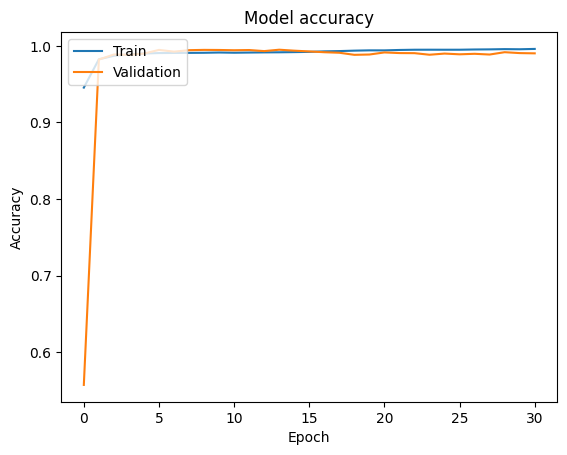

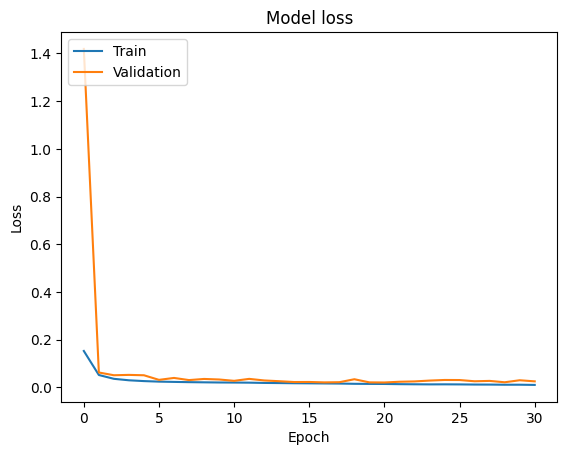

C:\Users\asus\AppData\Local\Temp\ipykernel_20132\273057548.py:74: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df1= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")


(112611, 44)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9314 - loss: 0.3869
Test Loss: 0.7427570223808289
Test Accuracy: 0.8969194889068604
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step
Test_Time(Sec) : 4.40737771987915
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.8969194838870093
Sensitivity : 0.8204067134357517
Specificity : 0.9734308954640714
Precision : 0.9686300824089412
Accuracy : 0.8969194838870093
F1_SCORE : 0.8883781756639806
Balance Accuracy : 0.8969188044499115


C:\Users\asus\AppData\Local\Temp\ipykernel_20132\273057548.py:109: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df2= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv')


(112611, 44)
Label
0    56306
1    56305
Name: count, dtype: int64
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Test_Time(Sec) : 3.3525390625
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9049915194785589
Sensitivity : 0.836355563449072
Specificity : 0.9736262565268355
Precision : 0.9694293478260869
Accuracy : 0.9049915194785589
F1_SCORE : 0.8979891496076506
Balance Accuracy : 0.9049909099879538


C:\Users\asus\AppData\Local\Temp\ipykernel_20132\273057548.py:146: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df3= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')


(112611, 44)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9309 - loss: 0.3511
Test Loss: 0.6294857263565063
Test Accuracy: 0.8994058966636658
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Test_Time(Sec) : 2.4049534797668457
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.8994059194927672
Sensitivity : 0.8273865553680846
Specificity : 0.9714240045465847
Precision : 0.9666147940657744
Accuracy : 0.8994059194927672
F1_SCORE : 0.891598086124402
Balance Accuracy : 0.8994052799573347


C:\Users\asus\AppData\Local\Temp\ipykernel_20132\273057548.py:179: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df4= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')


(112611, 44)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.9310 - loss: 0.3534
Test Loss: 0.6348052024841309
Test Accuracy: 0.899610161781311
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Test_Time(Sec) : 2.7239091396331787
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.8996101624175258
Sensitivity : 0.8277950448450404
Specificity : 0.9714240045465847
Precision : 0.9666307188186984
Accuracy : 0.8996101624175258
F1_SCORE : 0.8918419869311062
Balance Accuracy : 0.8996095246958126


C:\Users\asus\AppData\Local\Temp\ipykernel_20132\273057548.py:213: DtypeWarning: Columns (84) have mixed types. Specify dtype option on import or set low_memory=False.
  validation= pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')


(112612, 44)
Label
0    56425
1    56187
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.9844 - loss: 0.0367
Test Loss: 0.02101730741560459
Test Accuracy: 0.9913330674171448
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Test_Time(Sec) : 1.984623670578003
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9913330728519163
Sensitivity : 0.9994126755299269
Specificity : 0.983287549844927
Precision : 0.9834842461075013
Accuracy : 0.9913330728519163
F1_SCORE : 0.9913844850111225
Balance Accuracy : 0.9913501126874269


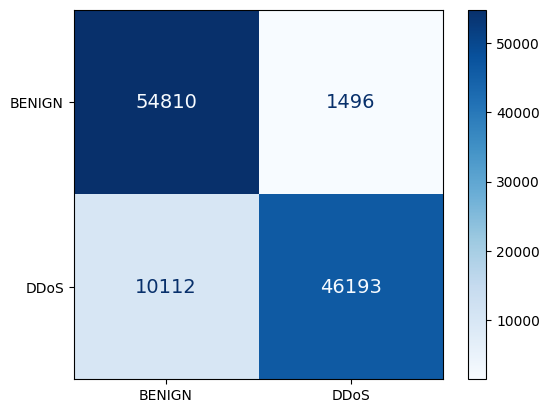

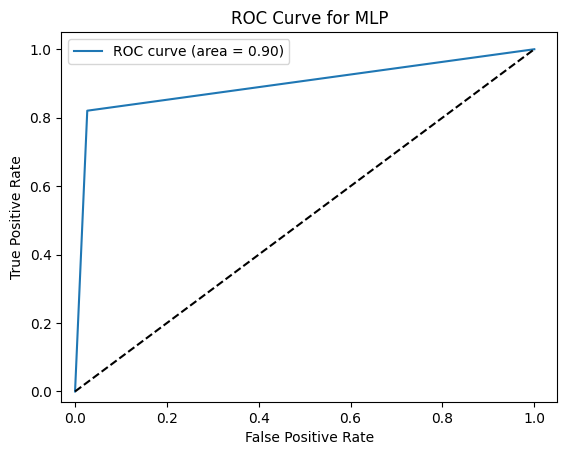

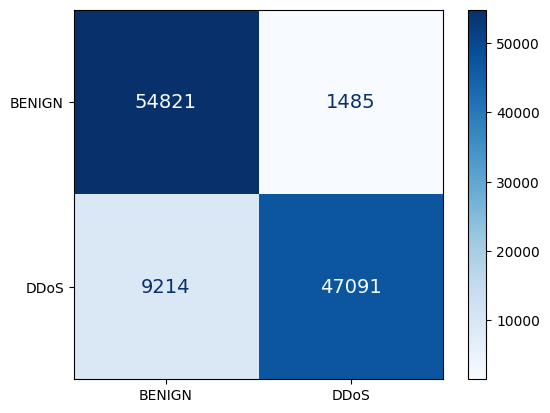

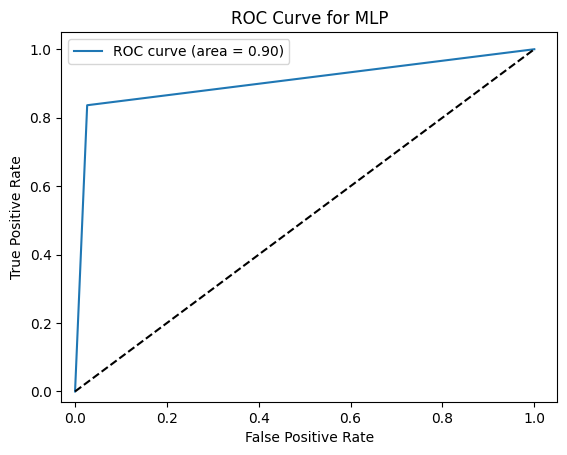

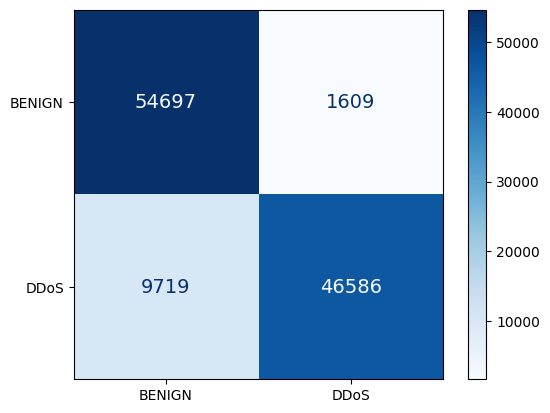

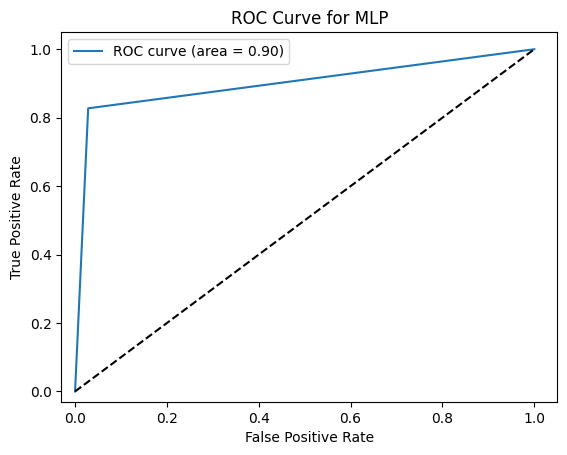

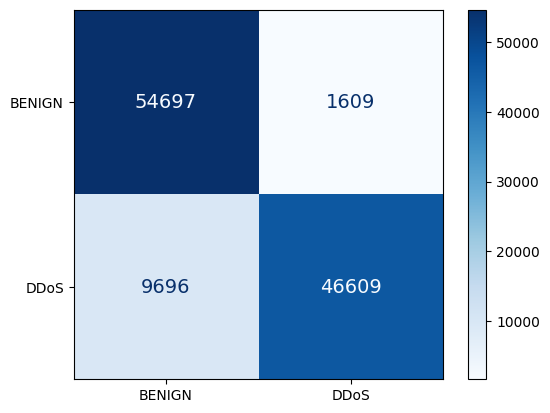

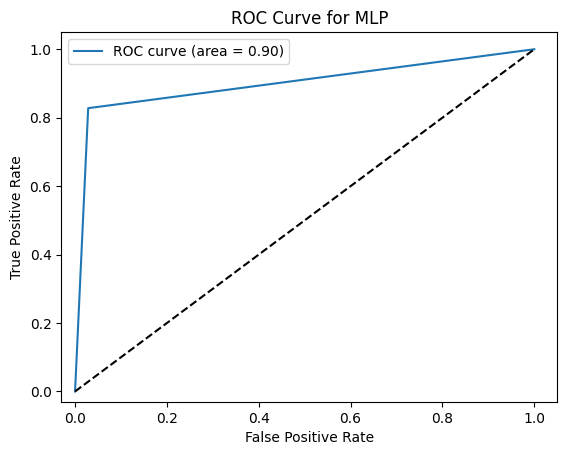

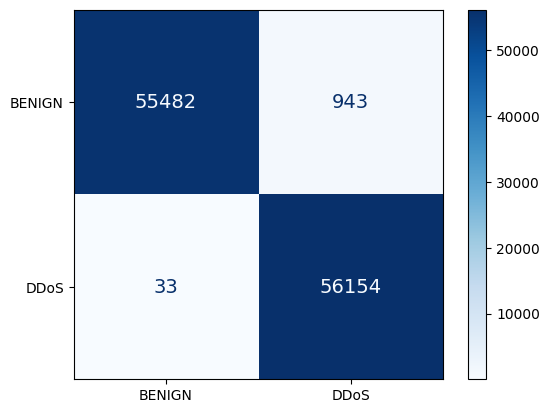

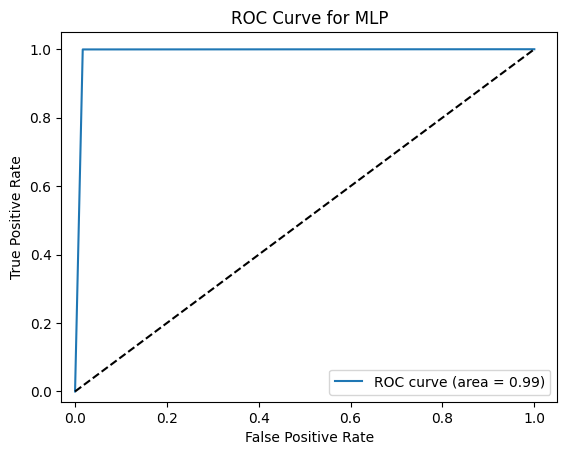

In [10]:

normalization_path = os.path.join(base_path, "Min_Max_Normalization")
Path = create_directory(normalization_path)
#print(Min_Max_Normalization_Path)

current_dir_name = os.path.basename(Path)

X = df.iloc[:,:-1]  # Drop the label column to get features
y_train = df.iloc[:,-1:]
X_train=Normalization(X)

Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv")
Validation_set=Validation_set[Features]
Validation_set['Label']=[0 if x == 'BENIGN' else 1 for x in Validation_set['Label']]
X_val=Validation_set.iloc[:,:-1]
X_val=Normalization(X_val)
y_val=Validation_set['Label']



#df= pd.read_csv(r'C:\Users\Student\RAGHU\CICDDoS2019_FROM_JULY_2024\4L_DATASET\4L_INBOUND_DATASET\Original\REPLACE_NEGATIVE\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
before_memory = psutil.Process().memory_info().rss
start=time.time()
# Fit the model with early stopping callback
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=50,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])
after_memory = psutil.Process().memory_info().rss
memory_used=after_memory-before_memory
end=time.time()
print("Memory_Used (MB):",memory_used/(1024*1024))
print("Train_Time(Sec) :", (end-start))

test_loss, test_accuracy = model.evaluate(X_val, y_val)
print(f'Validation Loss: {test_loss}')
print(f'Validation Accuracy: {test_accuracy}')
# Step 9: Evaluate the model on test data
model_filename = "4L_MLP_model_MIN_MAX_5_LAYERS_BATCH_1024.sav"
model_save_path = os.path.join(Path, model_filename)
pickle.dump(model, open(model_save_path,'wb'))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.savefig(os.path.join(Path, 'MLP_4L_35F_5_layers_validation_accuracy.png'))
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig(os.path.join(Path,'MLP_4L_35F_5_layers_validation_Loss.png'))
plt.show()





wb = xw.Book()
# Assuming you have trained the model and X_train, y_train are your training data
# X_test and y_test are your test data
# Also assuming normalization was applied to X_train, so apply the same transformation to X_test

df1= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")
df1=df1[Features]
df1['Label']=[0 if x == 'BENIGN' else 1 for x in df1['Label']]
print(df1.shape)
print(df1['Label'].value_counts())


X_test = df1.iloc[:,:-1]
y_test=df1['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D1_Dataset",Path)



df2= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv')
df2=df2[Features]
df2['Label']=[0 if x == 'BENIGN' else 1 for x in df2['Label']]
print(df2.shape)
print(df2['Label'].value_counts())


X_test = df2.iloc[:,:-1]
y_test=df2['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Loss: {test_loss}")
# print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
#wb = xw.Book()
Evaluation_Metrics(y_test, y_pred_binary,"D2_Dataset",Path)




df3= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')
df3=df3[Features]
df3['Label']=[0 if x == 'BENIGN' else 1 for x in df3['Label']]
print(df3.shape)
print(df3['Label'].value_counts())
X_test = df3.iloc[:,:-1]
y_test=df3['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D3_Dataset",Path)



df4= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')
df4=df4[Features]
df4['Label']=[0 if x == 'BENIGN' else 1 for x in df4['Label']]
print(df4.shape)
print(df4['Label'].value_counts())
X_test = df4.iloc[:,:-1]
y_test=df4['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D4_Dataset",Path)




validation= pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')
validation=validation[Features]
validation['Label']=[0 if x == 'BENIGN' else 1 for x in validation['Label']]
print(validation.shape)
print(validation['Label'].value_counts())
X_test = validation.iloc[:,:-1]
y_test=validation['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"Validation_Dataset", Path)



excel_filename = "Min_Max_Results.xlsx"
excel_save_path = os.path.join(Path, excel_filename)
wb.save(excel_save_path)
wb.close()

#### Quantile_Normalization

In [11]:
'''
normalization_path = os.path.join(base_path, "Quantile_Normalization")
Path = create_directory(normalization_path)
#print(Min_Max_Normalization_Path)

current_dir_name = os.path.basename(Path)

X = df.iloc[:,:-1]  # Drop the label column to get features
y_train = df.iloc[:,-1:]
X_train=Quantile_Transform(X)

Validation_set= pd.read_csv(r"D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv")
Validation_set=Validation_set[Features]
Validation_set['Label']=[0 if x == 'BENIGN' else 1 for x in Validation_set['Label']]
X_val=Validation_set.iloc[:,:-1]
X_val=Quantile_Transform(X_val)
y_val=Validation_set['Label']



#df= pd.read_csv(r'C:\Users\Student\RAGHU\CICDDoS2019_FROM_JULY_2024\4L_DATASET\4L_INBOUND_DATASET\Original\REPLACE_NEGATIVE\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
before_memory = psutil.Process().memory_info().rss
start=time.time()
# Fit the model with early stopping callback
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=50,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])
after_memory = psutil.Process().memory_info().rss
memory_used=after_memory-before_memory
end=time.time()
print("Memory_Used (MB):",memory_used/(1024*1024))
print("Train_Time(Sec) :", (end-start))

test_loss, test_accuracy = model.evaluate(X_val, y_val)
print(f'Validation Loss: {test_loss}')
print(f'Validation Accuracy: {test_accuracy}')
# Step 9: Evaluate the model on test data
model_filename = "4L_MLP_model_MIN_MAX_5_LAYERS_BATCH_1024.sav"
model_save_path = os.path.join(Path, model_filename)
pickle.dump(model, open(model_save_path,'wb'))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.savefig(os.path.join(Path, 'MLP_4L_15F_5_layers_validation_accuracy.png'))
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig(os.path.join(Path,'MLP_4L_15F_5_layers_validation_Loss.png'))
plt.show()





wb = xw.Book()
# Assuming you have trained the model and X_train, y_train are your training data
# X_test and y_test are your test data
# Also assuming normalization was applied to X_train, so apply the same transformation to X_test

df1= pd.read_csv(r"D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")
df1=df1[Features]
df1['Label']=[0 if x == 'BENIGN' else 1 for x in df1['Label']]
print(df1.shape)
print(df1['Label'].value_counts())


X_test = df1.iloc[:,:-1]
y_test=df1['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D1_Dataset",Path)



df2= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv')
df2=df2[Features]
df2['Label']=[0 if x == 'BENIGN' else 1 for x in df2['Label']]
print(df2.shape)
print(df2['Label'].value_counts())


X_test = df2.iloc[:,:-1]
y_test=df2['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Loss: {test_loss}")
# print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
#wb = xw.Book()
Evaluation_Metrics(y_test, y_pred_binary,"D2_Dataset",Path)




df3= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')
df3=df3[Features]
df3['Label']=[0 if x == 'BENIGN' else 1 for x in df3['Label']]
print(df3.shape)
print(df3['Label'].value_counts())
X_test = df3.iloc[:,:-1]
y_test=df3['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D3_Dataset",Path)



df4= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')
df4=df4[Features]
df4['Label']=[0 if x == 'BENIGN' else 1 for x in df4['Label']]
print(df4.shape)
print(df4['Label'].value_counts())
X_test = df4.iloc[:,:-1]
y_test=df4['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D4_Dataset",Path)




validation= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\1_CR_DATASET\ValidationDataset\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')
validation=validation[Features]
validation['Label']=[0 if x == 'BENIGN' else 1 for x in validation['Label']]
print(validation.shape)
print(validation['Label'].value_counts())
X_test = validation.iloc[:,:-1]
y_test=validation['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"Validation_Dataset", Path)



excel_filename = "Quantile_WVC_15F_RANDOM_1_Results.xlsx"
excel_save_path = os.path.join(Path, excel_filename)
wb.save(excel_save_path)
wb.close()
'''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 731-732: truncated \UXXXXXXXX escape (3523903426.py, line 1)

Standardization

In [ ]:
'''
normalization_path = os.path.join(base_path, "Standardization_Normalization")
Path = create_directory(normalization_path)
#print(Min_Max_Normalization_Path)

current_dir_name = os.path.basename(Path)

X = df.iloc[:,:-1]  # Drop the label column to get features
y_train = df.iloc[:,-1:]
X_train=Standardization(X)

Validation_set= pd.read_csv(r"D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv")
Validation_set=Validation_set[Features]
Validation_set['Label']=[0 if x == 'BENIGN' else 1 for x in Validation_set['Label']]
X_val=Validation_set.iloc[:,:-1]
X_val=Standardization(X_val)
y_val=Validation_set['Label']



#df= pd.read_csv(r'C:\Users\Student\RAGHU\CICDDoS2019_FROM_JULY_2024\4L_DATASET\4L_INBOUND_DATASET\Original\REPLACE_NEGATIVE\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
before_memory = psutil.Process().memory_info().rss
start=time.time()
# Fit the model with early stopping callback
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=50,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])
after_memory = psutil.Process().memory_info().rss
memory_used=after_memory-before_memory
end=time.time()
print("Memory_Used (MB):",memory_used/(1024*1024))
print("Train_Time(Sec) :", (end-start))

test_loss, test_accuracy = model.evaluate(X_val, y_val)
print(f'Validation Loss: {test_loss}')
print(f'Validation Accuracy: {test_accuracy}')
# Step 9: Evaluate the model on test data
model_filename = "4L_MLP_model_MIN_MAX_5_LAYERS_BATCH_1024.sav"
model_save_path = os.path.join(Path, model_filename)
pickle.dump(model, open(model_save_path,'wb'))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.savefig(os.path.join(Path, 'MLP_4L_15F_5_layers_validation_accuracy.png'))
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig(os.path.join(Path,'MLP_4L_15F_5_layers_validation_Loss.png'))
plt.show()





wb = xw.Book()
# Assuming you have trained the model and X_train, y_train are your training data
# X_test and y_test are your test data
# Also assuming normalization was applied to X_train, so apply the same transformation to X_test

df1= pd.read_csv(r"D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")
df1=df1[Features]
df1['Label']=[0 if x == 'BENIGN' else 1 for x in df1['Label']]
print(df1.shape)
print(df1['Label'].value_counts())


X_test = df1.iloc[:,:-1]
y_test=df1['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D1_Dataset",Path)



df2= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv')
df2=df2[Features]
df2['Label']=[0 if x == 'BENIGN' else 1 for x in df2['Label']]
print(df2.shape)
print(df2['Label'].value_counts())


X_test = df2.iloc[:,:-1]
y_test=df2['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Loss: {test_loss}")
# print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
#wb = xw.Book()
Evaluation_Metrics(y_test, y_pred_binary,"D2_Dataset",Path)




df3= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')
df3=df3[Features]
df3['Label']=[0 if x == 'BENIGN' else 1 for x in df3['Label']]
print(df3.shape)
print(df3['Label'].value_counts())
X_test = df3.iloc[:,:-1]
y_test=df3['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D3_Dataset",Path)



df4= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')
df4=df4[Features]
df4['Label']=[0 if x == 'BENIGN' else 1 for x in df4['Label']]
print(df4.shape)
print(df4['Label'].value_counts())
X_test = df4.iloc[:,:-1]
y_test=df4['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D4_Dataset",Path)




validation= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\1_CR_DATASET\ValidationDataset\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')
validation=validation[Features]
validation['Label']=[0 if x == 'BENIGN' else 1 for x in validation['Label']]
print(validation.shape)
print(validation['Label'].value_counts())
X_test = validation.iloc[:,:-1]
y_test=validation['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"Validation_Dataset", Path)



excel_filename = "Standardization_WVC_15F_RANDOM_1_Results.xlsx"
excel_save_path = os.path.join(Path, excel_filename)
wb.save(excel_save_path)
wb.close()
'''

In [ ]:
# df = pd.read_csv(r'D:\RAGHU1\CICDDoS2019\4L_DATASET\4L_INBOUND_DATASET\Original\REPLACE_NEGATIVE\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')
# df['Label'].value_counts()

In [ ]:
# df['Label'].unique()

In [ ]:
# df1= pd.read_csv(r"D:\RAGHU1\CICDDoS2019\TEST_DATASET\without_imputation\Replace_Negative_Values\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")
# df1['Label'].value_counts()

In [ ]:
# validation= pd.read_csv(r'D:\RAGHU1\CICDDoS2019\1_CR_DATASET\ValidationDataset\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')
# validation['Label'].value_counts()